In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
from skimage import data
from sklearn.cluster import KMeans

image = data.chelsea()
pixels = image.reshape(-1,3)

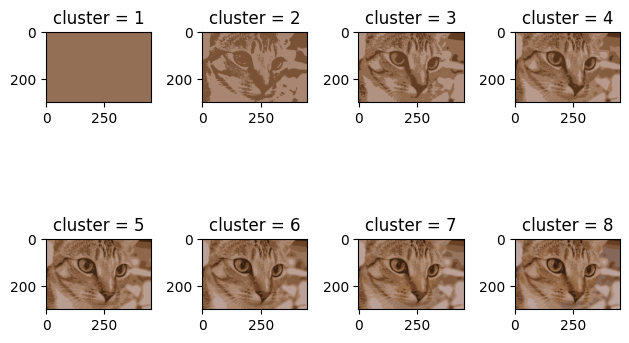

In [17]:
n_start = 1
n_end = 8
row_num = 2

segments = []
for n in range(n_start, n_end + 1):
    kmeans = KMeans(n, random_state=42)
    labels = kmeans.fit_predict(pixels)
    segments.append(kmeans.cluster_centers_[labels].reshape(image.shape).astype(np.uint8))

fig, axes = plt.subplots(row_num, n_end//row_num)
for idx, ax in enumerate(axes.flatten()):
    ax.set_title(f"cluster = {idx + 1}")
    ax.imshow(segments[idx])

plt.tight_layout()
plt.show()

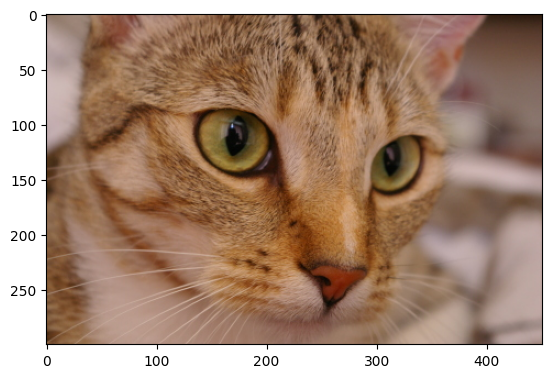

In [12]:
plt.imshow(image)

In [3]:
from sklearn.datasets import load_digits

X_digits, y_digits = load_digits(return_X_y=True)
X_train, y_train = X_digits[:1400], y_digits[:1400]
X_test, y_test = X_digits[1400:], y_digits[1400:]

In [21]:
from sklearn.linear_model import LogisticRegression

n_labeled = 50
log_reg = LogisticRegression(max_iter=10000)
log_reg.fit(X_train[:n_labeled], y_train[:n_labeled])
log_reg.score(X_test, y_test)

0.7581863979848866

In [23]:
k = 50
Kmeans = KMeans(k, random_state=42)
Kmeans.fit_predict(X_train, y_train)
center_x = Kmeans.cluster_centers_

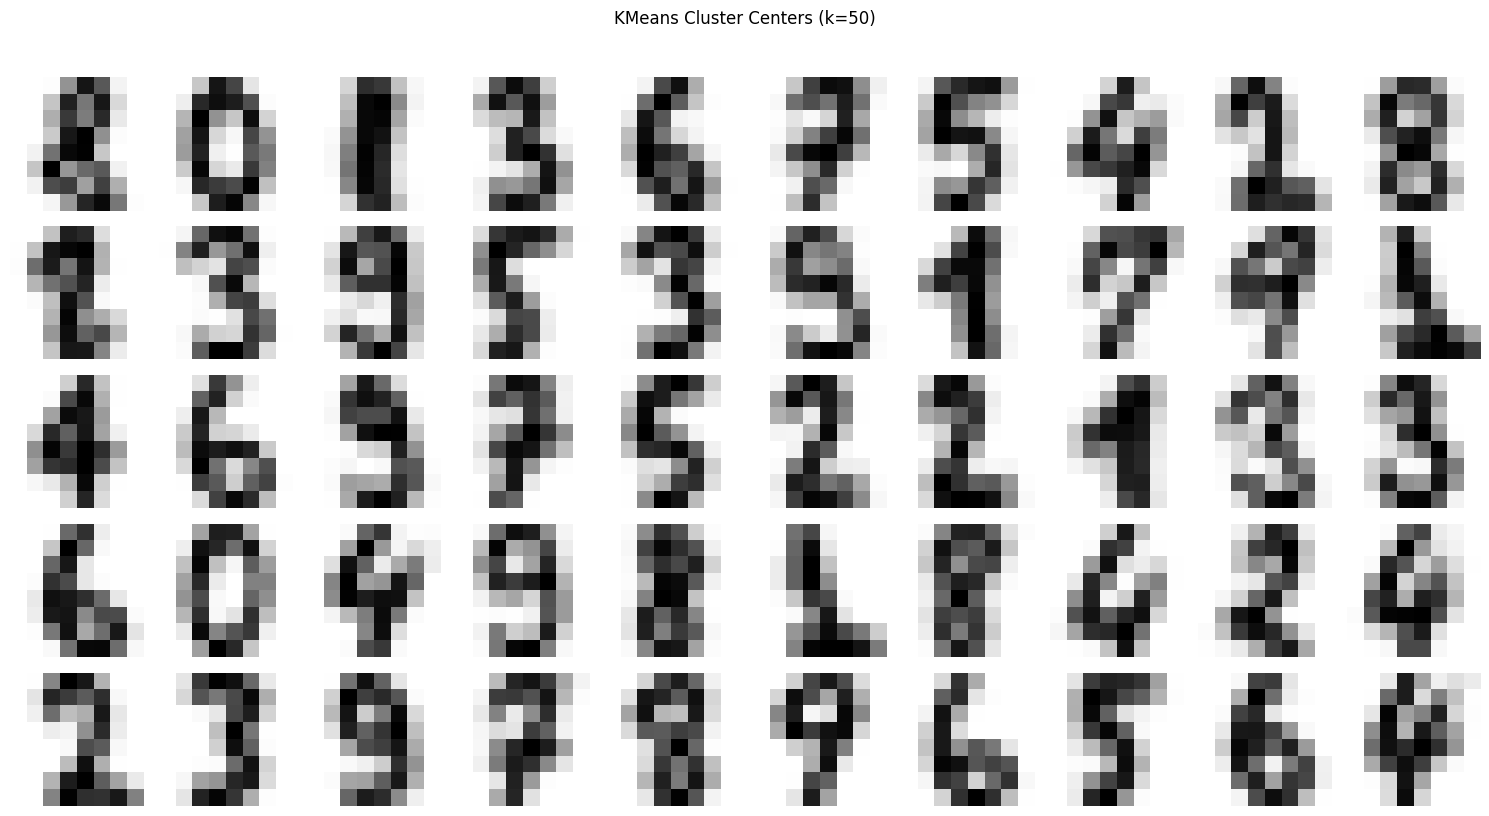

In [28]:
fig, axes = plt.subplots(5, 10, figsize=(15, 8))

for ax, center in zip(axes.flatten(), center_x):
    ax.imshow(center.reshape(8, 8), cmap='binary')
    ax.axis('off')

plt.suptitle("KMeans Cluster Centers (k=50)", y=1.02)
plt.tight_layout()
plt.show()

In [29]:
center_y = np.array([8,0,1,3,6,7,5,4,2,8,
                     2,3,9,5,3,9,1,7,9,1,
                     4,6,9,7,5,2,2,1,3,3,
                     6,0,4,9,8,1,8,4,2,4,
                     2,3,9,7,8,9,6,5,6,4])


In [30]:
log_reg = LogisticRegression(max_iter=10000)
log_reg.fit(center_x, center_y)
log_reg.score(X_test, y_test)

0.8463476070528967

In [36]:
y_train_propagated = np.empty(len(X_train), dtype=np.int64)
for i in range(k):
    y_train_propagated[Kmeans.labels_ == i] = center_y[i]

In [37]:
log_reg.fit(X_train, y_train_propagated)
log_reg.score(X_test, y_test)

0.8690176322418136

In [ ]:
percentile_closest = 50
X_cluster_dist = X_digits_dist[np.arange(len(X_train)), kmeans.labels_]

In [ ]:
percentile_closest = 50

X_cluster_dist = X_digits_dist[np.arrage(len(X_train)), kmeans.labels_]